<a href="https://colab.research.google.com/github/MarioBetancourt04/Aprendizaje-Por-Refuerzo---Laboratorio-6/blob/main/Laboratorio6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***LABORATORIO 6 - POLICY GRADIENT METHODS***
En este cuadernillo de Python se resuelven los ejercicios de implementación del laboratorio 6 del curso de Aprendizaje por Refuerzo de la Universidad del Valle de Guatemala.

## **1) REINFORCE**
REINFORCE es un algoritmo de aprendizaje por gradiente de política que optimiza las decisiones de un agente mediante estimaciones de *Monte Carlo*. Este usa retornos de episodios completos.

El update de REINFORCE es:

$$\mathbb{\theta}_{t+1} = \mathbb{\theta}_t + \alpha G_t \nabla_{\theta} \log \pi_{\theta}(A_t | S_t)$$

Esta expresión se obtiene usando el teorema del gradiente de política, el cual establece que el gradiente de la medida de rendimiento $J(\mathbb{\theta})$ de una política $\pi_\mathbb{\theta}(s)$ parametrizada respecto a $\mathbb{\theta}$ puede calcularse sin diferenciar la política, usando una regla de proporcionalidad:

$$\nabla J(\mathbb{\theta}) \propto \sum_s \mu(s) \sum_a q_{\pi} (s,a) ∇ \pi(a|s,\mathbb{\theta}_t) $$

Donde $\mu(s)$ es una distribución on-policy bajo $\pi$, es una distribución que indica la cantidad de tiempo que el agente pasa en cada estado. Esto también puede escribirse en forma de un valor esperado:

$$\nabla J(\mathbb{\theta})  =  \mathbb{E}_\pi \left[ \sum_a q_{\pi} (s,a) ∇ \pi(a|s,\mathbb{\theta}_t) \right]$$

Para obtener el update de REINFORCE, la expresión de antes se modifica multiplicando y dividiendo entre $\pi$ para reemplazar la función de valor de acción por el retorno en el paso $t$ porque

$$\mathbb{E}_\pi [G_t|S_t,A_t] = q_\pi(St, A_t)$$

La nueva expresión es:

$$\nabla J(\mathbb{\theta})  =  \mathbb{E}_\pi \left[ G_t \frac{\nabla \pi(A_t|s,\mathbb{\theta}_t)}{ \pi(A_t|s,\mathbb{\theta}_t)}  \right]$$

La ventaja de utilizar esta forma es que el retorno es una cantidad que se puede *muestrear* durante cada paso $t$.

El paso de REINFORCE se obtiene al instanciar un algoritmo de gradient ascent estocástico.

### **1.1) PSEUDOCÓDIGO**

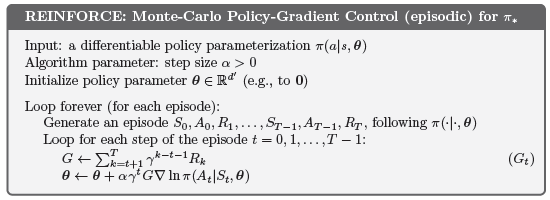

Un problema importante con esta implementación de Policy Gradient es que la varianza de $G_t$ es alta. Esto puede resolverse si se hace una comparación de la función de valor a una línea base (baseline) arbitraria.

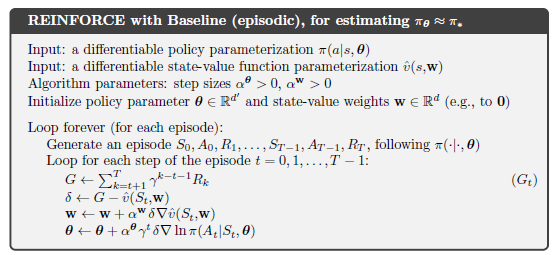

### **1.2) IMPLEMENTACIÓN**

Para implementar el algoritmo de aprendizaje REINFORCE con un baseline $V_\pi(s)$ calculan *ambas* la política $\pi(a,s|\mathbb{\theta})$ como la función de valor parametrizada $\hat{v}(s,\mathbb{w})$ a través de dos modelos de redes neuronales. Esto se hace porque *las redes neuronales pueden ser utilizadas como aproximadores de función universales*. Para ello se utiliza la librería PyTorch.

In [1]:
# Dependencias permitidas por el laboratorio y utilidades de la biblioteca estandar.
import os
import random
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


In [2]:
# Función para generar semillas
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [3]:
class PolicyNetwork(nn.Module):
    """Politica gaussiana pi(a|s) para REINFORCE."""

    def __init__(self, state_dim, action_dim):
        super().__init__()
        # Cuerpo exigido: estado -> 64 ReLU -> 64 ReLU.
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.mu_head = nn.Linear(64, action_dim)

        # Un unico sigma produce la covarianza isotropica sigma^2 I.
        # Se aprende log(sigma) para garantizar sigma > 0.
        self.log_std = nn.Parameter(torch.log(torch.tensor(0.5)))

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        mu = torch.tanh(self.mu_head(x))
        std = torch.exp(self.log_std).expand_as(mu)
        return mu, std


In [4]:
class ValueNetwork(nn.Module):
  """
  Aproximador de la función de valor V(s)
  usando redes neuronales.
  """
  def __init__(self, state_dim):
    super().__init__()
    self.fc1 = nn.Linear(state_dim, 64)
    self.fc2 = nn.Linear(64,64)
    self.v_head = nn.Linear(64,1)

  def forward(self, x):
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    x = self.v_head(x)
    return x

In [5]:
def compute_returns(rewards, gamma):
    """Calcula G_t = R_{t+1} + gamma G_{t+1} hacia atras."""
    returns = []
    G = 0.0
    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)
    return returns


def get_grad_norm(params):
    """Norma L2 conjunta de los gradientes almacenados en parametros."""
    squared_norm = 0.0
    for param in params:
        if param.grad is not None:
            squared_norm += param.grad.detach().pow(2).sum().item()
    return squared_norm ** 0.5


def get_tensor_grad_norm(grads):
    """Norma L2 de gradientes devueltos por torch.autograd.grad."""
    squared_norm = sum(
        grad.detach().pow(2).sum().item()
        for grad in grads
        if grad is not None
    )
    return squared_norm ** 0.5


In [6]:
def train_REINFORCE(
    env: gym.Env,
    num_episodes,
    gamma,
    lr_actor,
    lr_critic,
    seed,
):
    """Entrena REINFORCE Monte Carlo con una linea base separada."""
    set_seed(seed)
    env.action_space.seed(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    policy = PolicyNetwork(state_dim, action_dim)
    value = ValueNetwork(state_dim)
    optimizer_policy = torch.optim.Adam(policy.parameters(), lr=lr_actor)
    optimizer_value = torch.optim.Adam(value.parameters(), lr=lr_critic)

    episode_rewards = []
    grad_norms = []
    entropies = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        log_probs = []
        rewards = []
        states = []
        entropy_sum = 0.0
        done = False

        while not done:
            state_tensor = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
            mu, std = policy(state_tensor)
            dist = torch.distributions.Normal(mu, std)

            # sample(), no rsample(), implementa el estimador score-function.
            action = dist.sample()
            log_probs.append(dist.log_prob(action).sum())
            entropy_sum += dist.entropy().sum().item()
            states.append(state_tensor)

            action_env = action.clamp(-1.0, 1.0).squeeze(0).numpy()
            state, reward, terminated, truncated, _ = env.step(action_env)
            rewards.append(reward)
            done = terminated or truncated

        returns = torch.as_tensor(compute_returns(rewards, gamma), dtype=torch.float32)
        states_tensor = torch.cat(states)
        values = value(states_tensor).squeeze(-1)

        # A_t = G_t - V(S_t); detach evita actualizar el baseline con L_actor.
        advantages = returns - values.detach()
        policy_loss = -(torch.stack(log_probs) * advantages).sum()
        optimizer_policy.zero_grad()
        policy_loss.backward()
        grad_norm = get_grad_norm(policy.parameters())
        optimizer_policy.step()

        # La linea base se ajusta a los retornos Monte Carlo con MSE.
        value_loss = F.mse_loss(values, returns)
        optimizer_value.zero_grad()
        value_loss.backward()
        optimizer_value.step()

        total_reward = float(sum(rewards))
        episode_rewards.append(total_reward)
        grad_norms.append(grad_norm)
        entropies.append(entropy_sum / len(rewards))

        if (episode + 1) % 50 == 0:
            print(
                f"REINFORCE | Episodio {episode + 1:4d} | "
                f"Recompensa {total_reward:8.2f}"
            )

    return policy, value, episode_rewards, grad_norms, entropies


## **2) ACTOR-CRITIC**

En el algoritmo de aprendizaje Actor-Critic, el update utiliza el error TD en lugar del retorno $G_t$:

$$
\mathbb{\theta}_{t+1} = \mathbb{\theta}_{t} + \alpha \delta_t \frac{∇ \pi (A_t | S_t, \mathbb{\theta}_t)}{\pi (A_t | S_t, \mathbb{\theta}_t)}
$$

Donde

$$\delta_t = R_{t+1} + \gamma \hat{v}(S_{t+1}, \mathbb{w}) - \hat{v}(S_t, \mathbb{w})$$

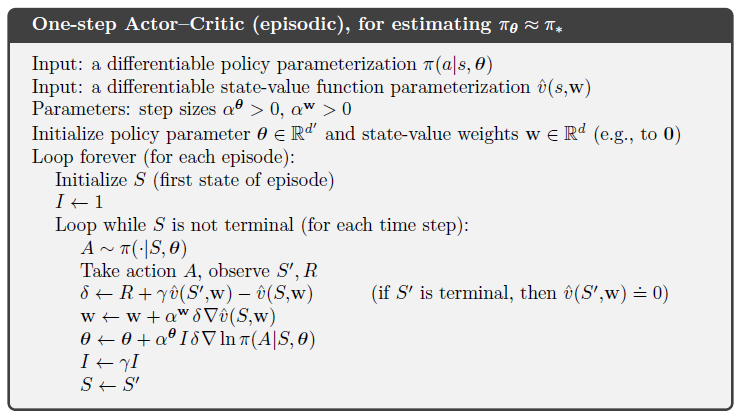

### **2.1) IMPLEMENTACIÓN**

In [7]:
class ActorCriticNetwork(nn.Module):
    """Actor y Critic con las dos capas ocultas compartidas."""

    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.mu_head = nn.Linear(64, action_dim)
        self.log_std = nn.Parameter(torch.log(torch.tensor(0.5)))
        self.v_head = nn.Linear(64, 1)

    def forward(self, x):
        features = F.relu(self.fc1(x))
        features = F.relu(self.fc2(features))
        mu = torch.tanh(self.mu_head(features))
        std = torch.exp(self.log_std).expand_as(mu)
        value = self.v_head(features)
        return mu, std, value


In [8]:
def train_actor_critic(env, num_episodes, gamma, lr, seed):
    """Entrena Actor-Critic en linea con una ventaja TD(0)."""
    set_seed(seed)
    env.action_space.seed(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    net = ActorCriticNetwork(state_dim, action_dim)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    actor_params = (
        list(net.fc1.parameters())
        + list(net.fc2.parameters())
        + list(net.mu_head.parameters())
        + [net.log_std]
    )

    episode_rewards = []
    grad_norms = []
    entropies = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        done = False
        total_reward = 0.0
        episode_grad_norms = []
        episode_entropies = []

        while not done:
            state_tensor = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
            mu, std, value = net(state_tensor)
            dist = torch.distributions.Normal(mu, std)
            action = dist.sample()
            log_prob = dist.log_prob(action).sum()
            entropy = dist.entropy().sum()

            action_env = action.clamp(-1.0, 1.0).squeeze(0).numpy()
            next_state, reward, terminated, truncated, _ = env.step(action_env)
            done = terminated or truncated

            next_state_tensor = torch.as_tensor(
                next_state, dtype=torch.float32
            ).unsqueeze(0)
            with torch.no_grad():
                _, _, next_value = net(next_state_tensor)
                # Solo una terminacion real anula el bootstrap; una truncacion no.
                bootstrap = 0.0 if terminated else 1.0
                td_target = reward + gamma * next_value.squeeze() * bootstrap

            # delta_t estima A(S_t,A_t) y no recibe gradiente en L_actor.
            td_error = td_target - value.squeeze()
            actor_loss = -log_prob * td_error.detach()
            critic_loss = 0.5 * td_error.pow(2)

            # autograd.grad mide solo el Actor. Medir despues de loss.backward()
            # mezclaria el gradiente del Critic en las capas compartidas.
            actor_grads = torch.autograd.grad(
                actor_loss,
                actor_params,
                retain_graph=True,
                allow_unused=True,
            )
            episode_grad_norms.append(get_tensor_grad_norm(actor_grads))

            optimizer.zero_grad()
            (actor_loss + critic_loss).backward()
            optimizer.step()

            episode_entropies.append(entropy.item())
            total_reward += reward
            state = next_state

        episode_rewards.append(float(total_reward))
        grad_norms.append(float(np.mean(episode_grad_norms)))
        entropies.append(float(np.mean(episode_entropies)))

        if (episode + 1) % 50 == 0:
            print(
                f"Actor-Critic | Episodio {episode + 1:4d} | "
                f"Recompensa {total_reward:8.2f}"
            )

    return net, episode_rewards, grad_norms, entropies


# **3) ENTORNO DE PRUEBAS**

In [9]:
%pip install "gymnasium[box2d]" -q



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [10]:
SEED = 42
GAMMA = 0.99
NUM_EPISODES = int(os.getenv("LAB6_EPISODES", "1000"))
LR_ACTOR = 1e-3
LR_CRITIC = 1e-3
LR_AC = 3e-4

# Gymnasium retiro v2 en versiones recientes; v3 conserva el mismo problema
# continuo y se usa solo como respaldo para poder reproducir el laboratorio.
ENV_NAME = "LunarLanderContinuous-v2"
try:
    gym.make(ENV_NAME).close()
except Exception:
    ENV_NAME = "LunarLanderContinuous-v3"

print(f"Entorno utilizado: {ENV_NAME}")
print(f"PyTorch: {torch.__version__} | Gymnasium: {gym.__version__}")


Entorno utilizado: LunarLanderContinuous-v3
PyTorch: 2.10.0+cu128 | Gymnasium: 1.2.2


/home/chris/python-envs/cv-ml-env/lib/python3.14/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment LunarLanderContinuous-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


### **3.1) ENTRENAMIENTO DE REINFORCE**


In [11]:
env_reinforce = gym.make(ENV_NAME)
policy, value_net, reinforce_rewards, reinforce_grad_norms, reinforce_entropies = train_REINFORCE(
    env_reinforce,
    NUM_EPISODES,
    GAMMA,
    LR_ACTOR,
    LR_CRITIC,
    SEED,
)
env_reinforce.close()


REINFORCE | Episodio   50 | Recompensa  -171.25


REINFORCE | Episodio  100 | Recompensa  -155.30


REINFORCE | Episodio  150 | Recompensa  -333.05


REINFORCE | Episodio  200 | Recompensa  -416.14


REINFORCE | Episodio  250 | Recompensa   -71.14


...

REINFORCE | Episodio  800 | Recompensa  -273.90


REINFORCE | Episodio  850 | Recompensa  -343.96


REINFORCE | Episodio  900 | Recompensa    27.22


REINFORCE | Episodio  950 | Recompensa    20.35


REINFORCE | Episodio 1000 | Recompensa    -8.91


### **3.2) ENTRENAMIENTO DE ACTOR-CRITIC**


In [12]:
env_ac = gym.make(ENV_NAME)
ac_net, ac_rewards, ac_grad_norms, ac_entropies = train_actor_critic(
    env_ac,
    NUM_EPISODES,
    GAMMA,
    LR_AC,
    SEED,
)
env_ac.close()


Actor-Critic | Episodio   50 | Recompensa  -528.90


Actor-Critic | Episodio  100 | Recompensa  -618.57


Actor-Critic | Episodio  150 | Recompensa  -652.92


Actor-Critic | Episodio  200 | Recompensa  -407.38


Actor-Critic | Episodio  250 | Recompensa  -448.22


...

Actor-Critic | Episodio  800 | Recompensa  -153.92


Actor-Critic | Episodio  850 | Recompensa  -122.56


Actor-Critic | Episodio  900 | Recompensa  -112.31


Actor-Critic | Episodio  950 | Recompensa  -130.49


Actor-Critic | Episodio 1000 | Recompensa  -144.73


In [13]:
def moving_average(data, window=20):
    return np.convolve(data, np.ones(window) / window, mode="valid")


In [14]:
FIG_DIR = Path("figs")
RESULTS_DIR = Path("results")
FIG_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)


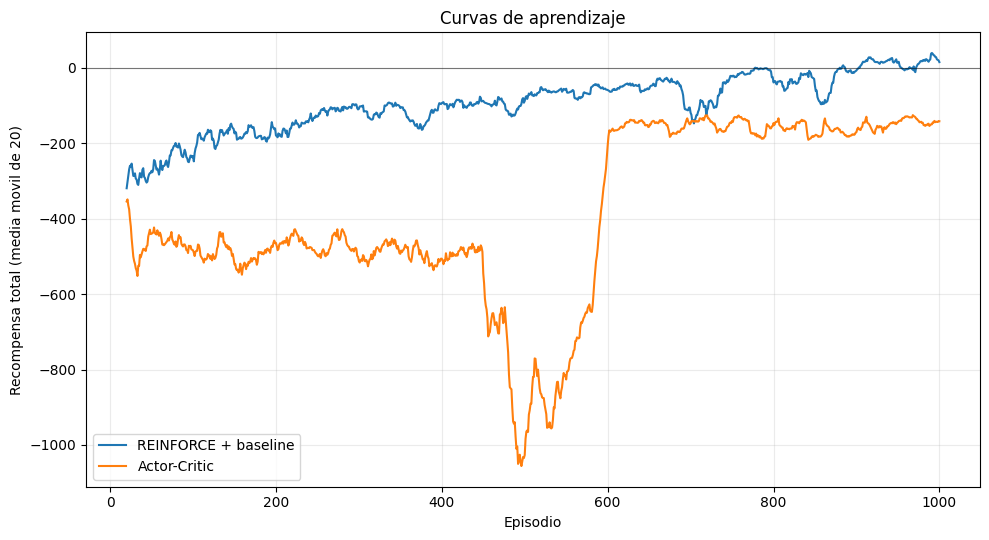

In [15]:
window = min(20, NUM_EPISODES)
episodes_ma = np.arange(window, NUM_EPISODES + 1)

plt.figure(figsize=(10, 5.5))
plt.plot(
    episodes_ma,
    moving_average(reinforce_rewards, window),
    label="REINFORCE + baseline",
)
plt.plot(
    episodes_ma,
    moving_average(ac_rewards, window),
    label="Actor-Critic",
)
plt.axhline(0, color="black", linewidth=0.8, alpha=0.5)
plt.xlabel("Episodio")
plt.ylabel("Recompensa total (media movil de 20)")
plt.title("Curvas de aprendizaje")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "curvas_aprendizaje.png", dpi=180)
plt.show()


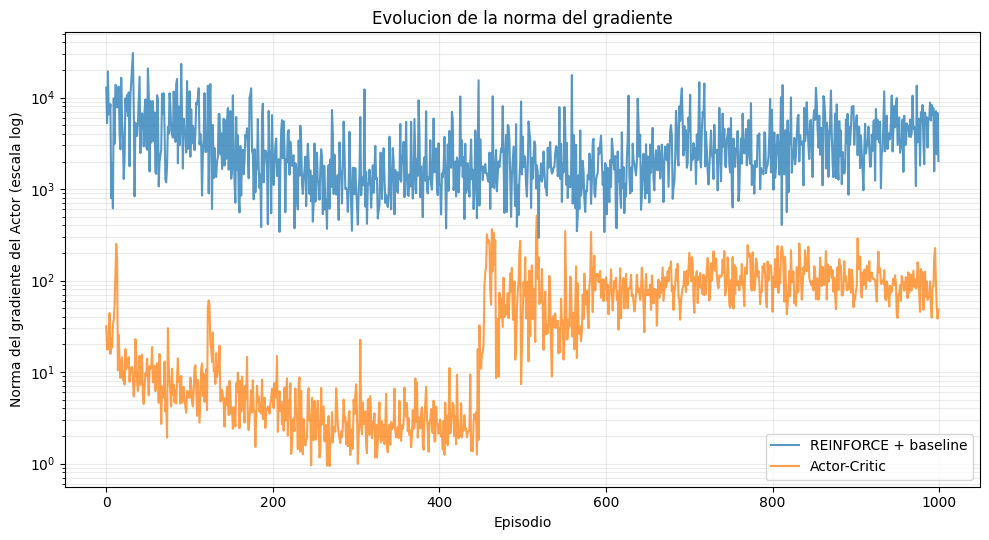

In [16]:
plt.figure(figsize=(10, 5.5))
plt.plot(reinforce_grad_norms, label="REINFORCE + baseline", alpha=0.75)
plt.plot(ac_grad_norms, label="Actor-Critic", alpha=0.75)
plt.yscale("log")
plt.xlabel("Episodio")
plt.ylabel("Norma del gradiente del Actor (escala log)")
plt.title("Evolucion de la norma del gradiente")
plt.legend()
plt.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.savefig(FIG_DIR / "norma_gradiente.png", dpi=180)
plt.show()


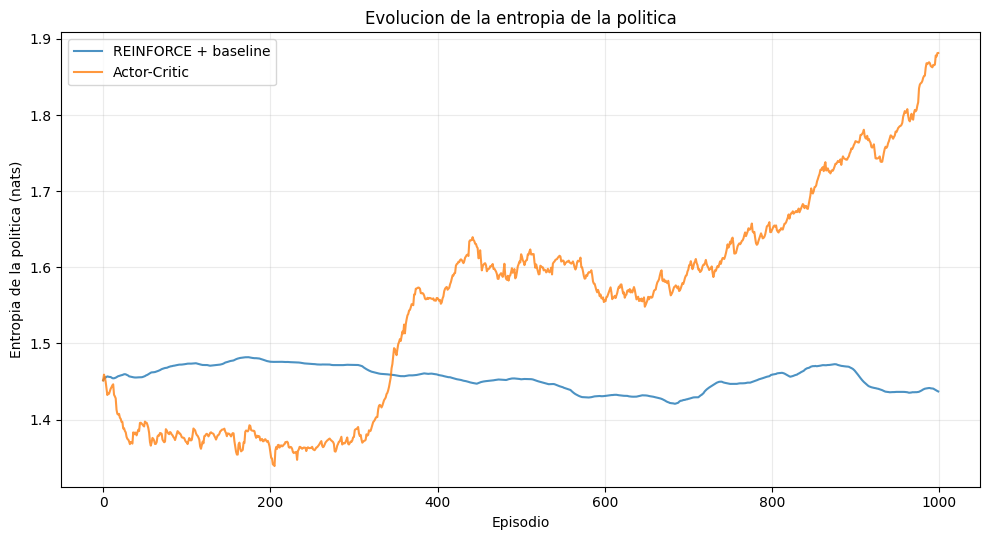

In [17]:
plt.figure(figsize=(10, 5.5))
plt.plot(reinforce_entropies, label="REINFORCE + baseline", alpha=0.8)
plt.plot(ac_entropies, label="Actor-Critic", alpha=0.8)
plt.xlabel("Episodio")
plt.ylabel("Entropia de la politica (nats)")
plt.title("Evolucion de la entropia de la politica")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "entropia.png", dpi=180)
plt.show()


### **3.3) RESUMEN NUMÉRICO Y PERSISTENCIA DE RESULTADOS**


In [18]:
def first_moving_average_crossing(rewards, threshold=0.0, window=20):
    window = min(window, len(rewards))
    curve = moving_average(rewards, window)
    crossings = np.flatnonzero(curve >= threshold)
    return None if len(crossings) == 0 else int(crossings[0] + window)


def metric_summary(name, rewards, grad_norms, entropies):
    rewards = np.asarray(rewards)
    grad_norms = np.asarray(grad_norms)
    entropies = np.asarray(entropies)
    q1, q3 = np.quantile(grad_norms, [0.25, 0.75])
    outlier_limit = q3 + 1.5 * (q3 - q1)
    return {
        "algoritmo": name,
        "recompensa_100_inicial": rewards[:100].mean(),
        "recompensa_100_final": rewards[-100:].mean(),
        "mejor_recompensa": rewards.max(),
        "cruce_media_movil_0": first_moving_average_crossing(rewards),
        "gradiente_mediano": np.median(grad_norms),
        "gradiente_maximo": grad_norms.max(),
        "episodios_gradiente_atipico": int((grad_norms > outlier_limit).sum()),
        "entropia_inicial": entropies[0],
        "entropia_final": entropies[-1],
    }


summaries = [
    metric_summary(
        "REINFORCE",
        reinforce_rewards,
        reinforce_grad_norms,
        reinforce_entropies,
    ),
    metric_summary(
        "Actor-Critic",
        ac_rewards,
        ac_grad_norms,
        ac_entropies,
    ),
]

for summary in summaries:
    print()
    print(summary["algoritmo"])
    for key, value in summary.items():
        if key != "algoritmo":
            print(f"  {key}: {value}")

np.savez(
    RESULTS_DIR / "lab6_metrics.npz",
    reinforce_rewards=reinforce_rewards,
    reinforce_grad_norms=reinforce_grad_norms,
    reinforce_entropies=reinforce_entropies,
    ac_rewards=ac_rewards,
    ac_grad_norms=ac_grad_norms,
    ac_entropies=ac_entropies,
)



REINFORCE
  recompensa_100_inicial: -259.7973358507375
  recompensa_100_final: 14.725630825299973
  mejor_recompensa: 96.69376783623348
  cruce_media_movil_0: 778
  gradiente_mediano: 2287.577112993805
  gradiente_maximo: 30709.210861726813
  episodios_gradiente_atipico: 72
  entropia_inicial: 1.451582670211792
  entropia_final: 1.4368784427642822

Actor-Critic
  recompensa_100_inicial: -446.0917342529124
  recompensa_100_final: -147.63138864326055
  mejor_recompensa: 18.312717939008976
  cruce_media_movil_0: None
  gradiente_mediano: 38.757564950585326
  gradiente_maximo: 515.61277521304
  episodios_gradiente_atipico: 19
  entropia_inicial: 1.4513510390529483
  entropia_final: 1.8815710250069113


### **3.4) VISUALIZACIÓN CON `env.render()`**


Para construir la visualización se consultó a Claude con el prompt: "¿Podrías
hacer una animación del método `render` del entorno `LunarLanderContinuous-v2`
que pueda colocarse como un video embebido en un cuadernillo de Google Colab?".
El prompt funcionó porque especificó el entorno, el mecanismo obligatorio
(`render`) y el medio de presentación (Colab). Se adaptó la respuesta para usar
`render_mode="rgb_array"`, evaluar la media determinista de la política y guardar
una secuencia compacta de seis cuadros reproducible también fuera de Colab.


In [19]:
def reinforce_forward(state_tensor):
    mu, _ = policy(state_tensor)
    return mu


def actor_critic_forward(state_tensor):
    mu, _, _ = ac_net(state_tensor)
    return mu


def run_episode_render(env_name, forward_fn, seed):
    """Ejecuta la media determinista y obtiene cuadros mediante env.render()."""
    env = gym.make(env_name, render_mode="rgb_array")
    state, _ = env.reset(seed=seed)
    frames = []
    total_reward = 0.0
    done = False

    while not done:
        frames.append(env.render())
        state_tensor = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            action = forward_fn(state_tensor).clamp(-1.0, 1.0)
        state, reward, terminated, truncated, _ = env.step(
            action.squeeze(0).numpy()
        )
        total_reward += reward
        done = terminated or truncated

    frames.append(env.render())
    env.close()
    return frames, float(total_reward)


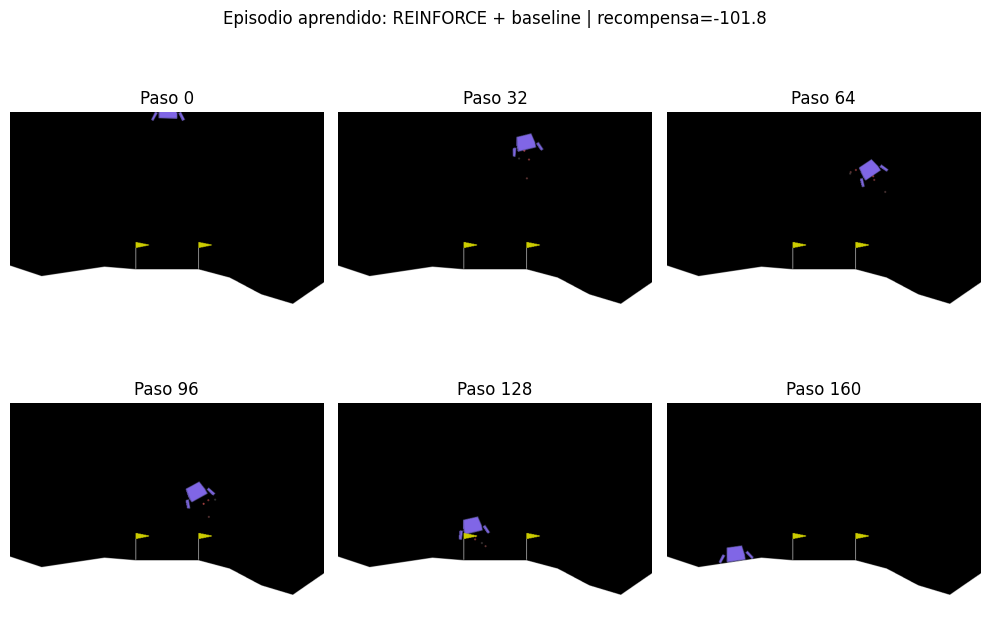

Politica visualizada: REINFORCE + baseline
Pasos: 160 | Recompensa: -101.79


In [20]:
# Se visualiza la politica con mejor recompensa media en los ultimos 100 episodios.
if np.mean(ac_rewards[-100:]) >= np.mean(reinforce_rewards[-100:]):
    selected_name = "Actor-Critic"
    selected_forward = actor_critic_forward
else:
    selected_name = "REINFORCE + baseline"
    selected_forward = reinforce_forward

render_frames, render_reward = run_episode_render(
    ENV_NAME, selected_forward, SEED + NUM_EPISODES
)
frame_indices = np.linspace(0, len(render_frames) - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for axis, frame_index in zip(axes.flat, frame_indices):
    axis.imshow(render_frames[frame_index])
    axis.set_title(f"Paso {frame_index}")
    axis.axis("off")
fig.suptitle(
    f"Episodio aprendido: {selected_name} | recompensa={render_reward:.1f}"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "episodio_render.png", dpi=180)
plt.show()
print(f"Politica visualizada: {selected_name}")
print(f"Pasos: {len(render_frames) - 1} | Recompensa: {render_reward:.2f}")
